``AAPredPlot().predict_sample(data, kind=...)`` is a multi-track sequence viewer for single-protein positional predictions: the per-residue profile (``kind='window'``) and the domain boundary-sensitivity curve (``kind='domain'``). ``kind`` selects the base renderer and ``data`` is the matching :meth:`AAPred.predict` frame; the base profile is stacked with optional extra tracks that share the residue-position x-axis (a CPP-importance profile, subcategory scale profiles, user annotation tracks, and a sequence row). We first fit an ``AAPred`` and generate the predictions to visualize (see [Breimann25]_):

**``predict_sample`` = the local (single-protein) view.** One stacked, residue-aligned figure; add only the tracks you need (any omitted input is simply skipped):

- **base** — the prediction: ``kind='window'`` (per-residue profile) or ``'domain'`` (boundary curve).
- **CPP importance** (``df_feat``), **subcategory profiles** (``subcats`` + scales), **annotation tracks** (``list_annotations`` — topology, pLDDT, flexibility, …), and the **sequence** row.

Contrast with ``predict_group`` (many proteins at once) and ``eval`` (model comparison).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import aaanalysis as aa
aa.options["verbose"] = False  # Disable verbosity
aa.plot_settings()

# DOM_GSEC example dataset, its feature set, and the AAontology scales (see [Breimann25]_)
df_seq = aa.load_dataset(name="DOM_GSEC")
labels = df_seq["label"].to_list()
df_feat = aa.load_features(name="DOM_GSEC").head(20)
df_scales = aa.load_scales()                    # amino-acid scale matrix (letters x scales)
df_cat = aa.load_scales(name="scales_cat")      # scale classification (scale_id -> subcategory)

sf = aa.SequenceFeature()
X = sf.feature_matrix(features=df_feat, df_parts=sf.get_df_parts(df_seq=df_seq))
aap = aa.AAPred(df_feat=df_feat, random_state=42).fit(X, labels)
aap_plot = aa.AAPredPlot()

# Per-residue and per-domain predictions for one protein (APP, P05067)
one = df_seq[df_seq["entry"] == "P05067"]
df_window = aap.predict(one[["entry", "sequence"]], level="window", tmd_len=15, step=5)
df_window_view = aap.predict(one[["entry", "sequence"]], level="window", tmd_len=15, step=40)
df_domain = aap.predict(one, level="domain", window=5)

**Per-residue profile.** ``kind='window'`` draws the profile with an optional decision ``threshold``, annotation tracks (``list_annotations``), a line ``color`` and axis labels; ``entry`` selects the protein when ``data`` holds several. Numeric annotation tracks render as line profiles:

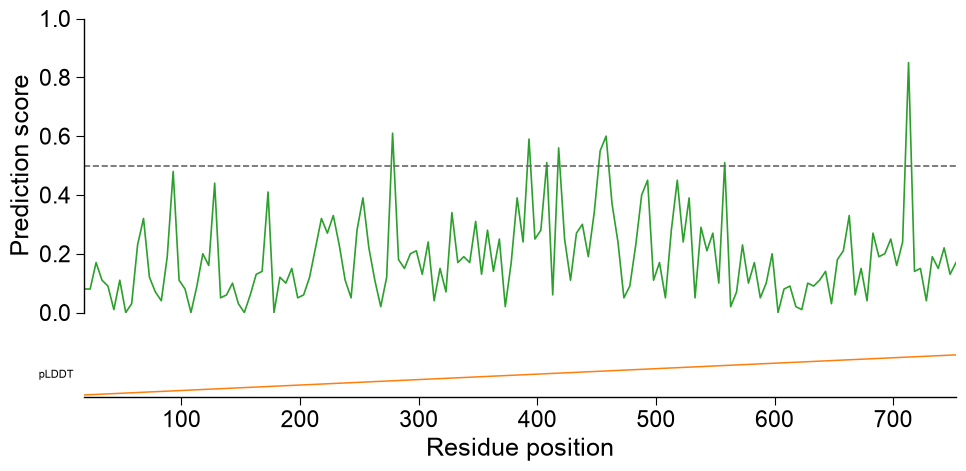

In [2]:
n_pos = len(df_window)
list_annotations = [{"values": np.linspace(0, 1, n_pos), "label": "pLDDT", "color": "tab:orange"}]
aap_plot.predict_sample(data=df_window, kind="window", entry="P05067", threshold=0.5,
                           list_annotations=list_annotations, color="tab:green", figsize=(10, 4.5),
                           xlabel="Residue position", ylabel="Prediction score")
plt.tight_layout()
plt.show()

**Multi-track sequence viewer.** Pass ``df_feat`` to add a **CPP-importance** track, ``subcats`` (with ``df_seq``, ``df_scales`` and ``df_cat``) to add one **subcategory** scale-profile track per name, and ``df_seq`` to draw the **sequence** row at the bottom (letters shown for short regions). Non-numeric ``list_annotations`` values fall back to a categorical ``imshow`` strip:

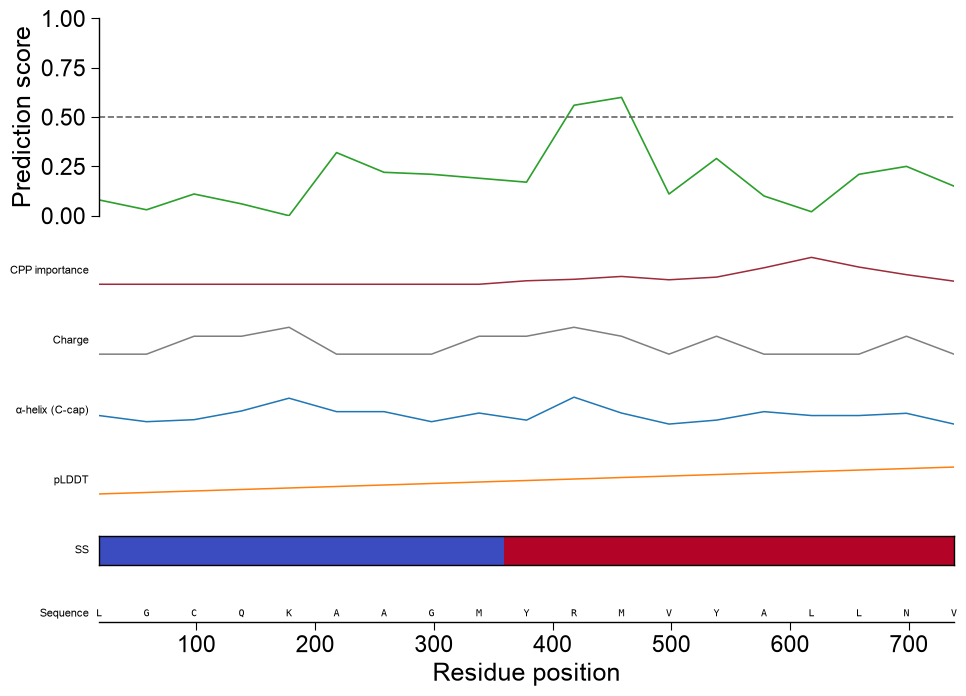

In [3]:
subcats = list(pd.unique(df_feat["subcategory"]))[:2]
n_view = len(df_window_view)
tracks = [{"values": np.linspace(0, 1, n_view), "label": "pLDDT", "color": "tab:orange"},
          {"values": ["H"] * (n_view // 2) + ["E"] * (n_view - n_view // 2), "label": "SS", "cmap": "coolwarm"}]
aap_plot.predict_sample(data=df_window_view, kind="window", entry="P05067", threshold=0.5,
                           df_seq=one, df_scales=df_scales, df_cat=df_cat, subcats=subcats,
                           df_feat=df_feat, list_annotations=tracks, color="tab:green")
plt.tight_layout()
plt.show()

**Highlight regions and zoom.** Pass ``highlight`` one ``(start, stop)`` tuple, or a list of them (1-based, inclusive residue positions), to shade those regions as a bright-cyan span across **every** track, so single or multiple parts are marked consistently down the whole stack. Set ``zoom=True`` to restrict the shared x-axis to the highlighted region(s); because the visible window shrinks, the sequence row then renders per-residue letters:

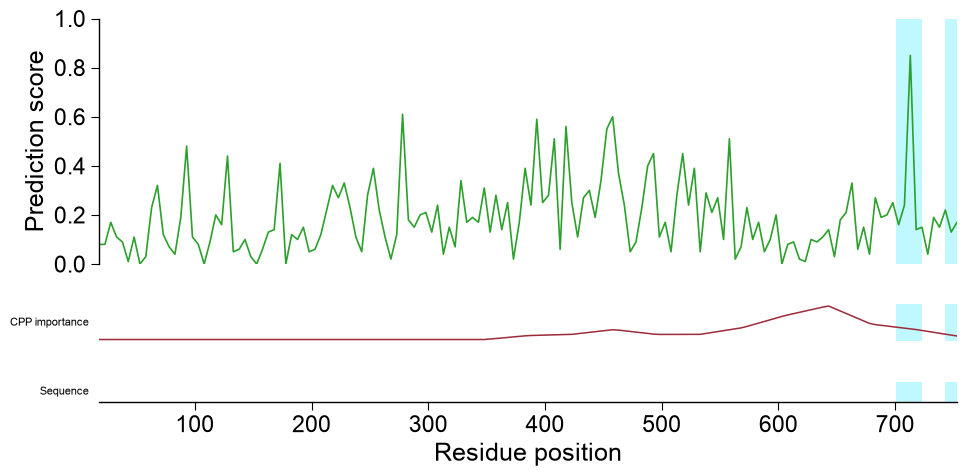

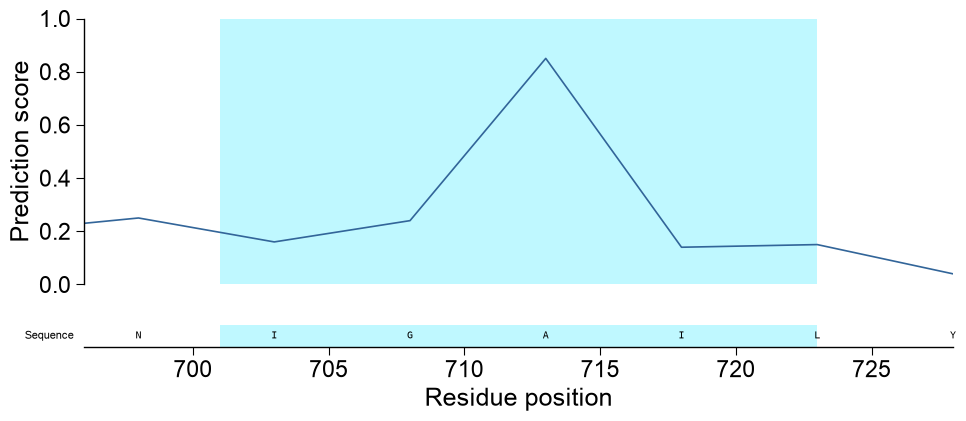

In [4]:
# TMD boundaries of APP (P05067) frame the regions of interest
tmd_start, tmd_stop = int(one["tmd_start"].iloc[0]), int(one["tmd_stop"].iloc[0])

# (a) mark two regions (the TMD and a downstream stretch) across every track
aap_plot.predict_sample(data=df_window, kind="window", entry="P05067", df_seq=one,
                           df_feat=df_feat, color="tab:green",
                           highlight=[(tmd_start, tmd_stop), (tmd_stop + 20, tmd_stop + 45)])
plt.tight_layout()
plt.show()

# (b) zoom into the TMD so the per-residue sequence letters become readable
aap_plot.predict_sample(data=df_window, kind="window", entry="P05067", df_seq=one,
                           highlight=(tmd_start, tmd_stop), zoom=True)
plt.tight_layout()
plt.show()

**Boundary sensitivity.** ``kind='domain'`` shows how the score depends on the exact domain boundary; the best offset is starred. The same extra tracks apply, with each offset mapped to residue ``tmd_start + offset``:

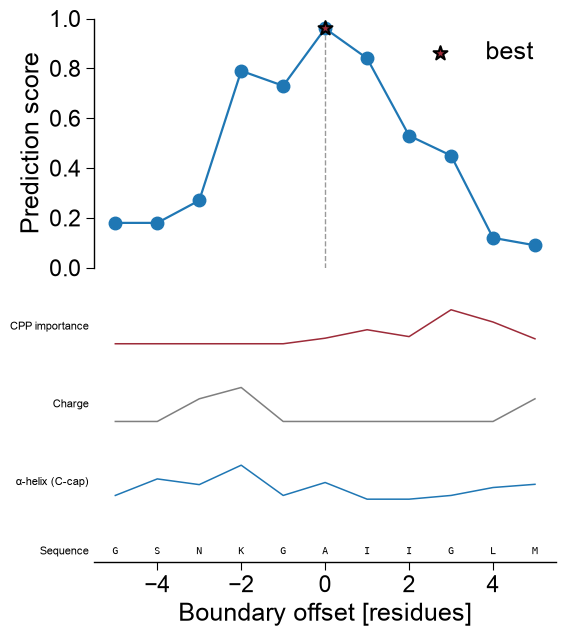

In [5]:
aap_plot.predict_sample(data=df_domain, kind="domain", entry="P05067", color="tab:blue",
                           df_seq=one, df_scales=df_scales, df_cat=df_cat, subcats=subcats,
                           df_feat=df_feat, figsize=(6, 4.5), xlabel="Boundary offset [residues]",
                           ylabel="Prediction score")
plt.tight_layout()
plt.show()

**``kind='sequence'``** renders a CPP-feature-map-style **heatmap over the whole protein**: rows are subcategories, columns are residue positions, and each cell is that subcategory's mean scale value at the residue. Pass ``subcats`` to choose the rows (or ``subcats=None`` for all, capped):

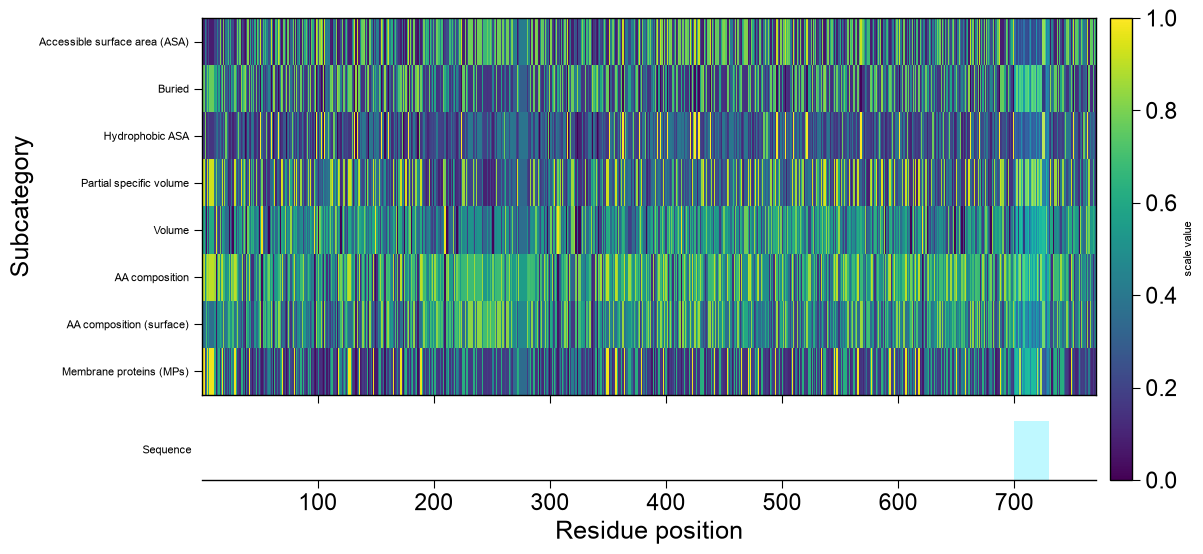

In [6]:
from aaanalysis.data_handling import load_scales
df_cat = load_scales(name="scales_cat")
subcats = list(dict.fromkeys(df_cat["subcategory"]))[:8]
aa.AAPredPlot().predict_sample(kind="sequence", df_seq=df_seq.head(1), subcats=subcats,
                               highlight=(700, 730))
plt.tight_layout()
plt.show()